# CNN (Convolution Neural Network)

+ 기존의 Fully-Connected 모델은 1차원의 데이터 말고 2차원 이상의 데이터를 사용하게 된다면, 해당 입력 데이터를 Flatten시켜 한 줄의 데이터로 만들어야 한다.
+ 이 과정에서 데이터의 손상이 발생하게 된다.
+ 이미지의 경우에는 상하좌우 이웃 픽셀의 정보가 손실된다.
+ 위 문제를 해결하기 위해 고안한 해결책이 바로 CNN이다.

**CNN 장점**
> + 단순 Fully-connected 보다 학습시킬 weight가 적다.
> + 학습과 연산에 속도가 빠르며, 효율적이다.
> + 이미지나 영상데이터를 처리할 때 사용한다.
---

**CNN의 접근**
![image](https://user-images.githubusercontent.com/28241676/152975808-7954439f-1887-4f3f-a624-26e36ba80398.png)

---
**이미지 표현 => Matrix**
![image](https://user-images.githubusercontent.com/28241676/152975987-95af8253-db60-4afd-a6fb-82aa04990a87.png)

## 패키지 Import

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm, notebook

## 데이터 살펴보기
### Fashion MNIST Dataset

In [10]:
# label_tags = ["티셔츠/탑", "트루저", "풀오버", "드레스", "코트", "샌들", "셔츠", "스니커", "가방", "앵클부츠"]
label_tags = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

train_dataset = pd.read_csv("Data/fashion-mnist_train.csv")
test_dataset = pd.read_csv("Data/fashion-mnist_test.csv")

# Split to Image & Label
train_images = (train_dataset.iloc[:, 1:].values).astype("float32")
train_labels = train_dataset["label"].values
test_images = (test_dataset.iloc[:, 1:].values).astype("float32")
test_labels = test_dataset["label"].values

In [11]:
# Split into Train, Valid Dataset
from sklearn.model_selection import train_test_split
train_images, valid_images, train_labels, valid_labels = train_test_split(train_images, 
                                                                          train_labels, 
                                                                          stratify = train_labels, 
                                                                          random_state = 42, 
                                                                          test_size = 0.2)

In [12]:
# Reshape image's size to check for ours
# (size, 785) => (size, 28, 28)
train_images = train_images.reshape(train_images.shape[0], 28, 28)
valid_images = valid_images.reshape(valid_images.shape[0], 28, 28)
test_images = test_images.reshape(test_images.shape[0], 28, 28)

In [13]:
# Check Train, Valid, Test Image's Shape
print("The Shape of Train Images: ", train_images.shape)
print("The Shape of Valid Images: ", valid_images.shape)
print("The Shape of Test Images: ", test_images.shape)

# Check Train, Valid Label's Shape
print("The Shape of Train Labels: ", train_labels.shape)
print("The Shape of Valid Labels: ", valid_labels.shape)
print("The Shape of Valid Labels: ", test_labels.shape)

The Shape of Train Images:  (48000, 28, 28)
The Shape of Valid Images:  (12000, 28, 28)
The Shape of Test Images:  (10000, 28, 28)
The Shape of Train Labels:  (48000,)
The Shape of Valid Labels:  (12000,)
The Shape of Valid Labels:  (10000,)


Label : Pullover


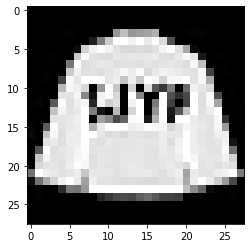

In [16]:
img = train_images[20]
label = train_labels[20]

print("Label :",label_tags[label])
plt.imshow(img, cmap='gray'); plt.show()

## Dataset 정의

In [18]:
class MyDataset(Dataset):
    def __init__(self, feature_data, label_data, num_classes = 10):
        self.x_data = feature_data
        self.y_data = label_data
        self.num_classes = num_classes

    def __len__(self):
        return len(self.x_data)

    def __getitem__(self, idx):
        # image
        img = self.x_data[idx] / 255.       # 명암값 정규화
        img = torch.FloatTensor(img)        # Tensor로 변환
        img = img.view(1, 28, 28)           # (channel, width, height)

        # label
        label = torch.tensor(self.y_data[idx])
        label = F.one_hot(label, num_classes = self.num_classes)        # one-hot 인코딩
        label = label.float()

        return img, label

In [20]:
label_tags = ['T-Shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt','Sneaker', 'Bag', 'Ankle Boot']

train_dataset = MyDataset(train_images, train_labels)
valid_dataset = MyDataset(valid_images, valid_labels)
test_dataset = MyDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
valid_loader = DataLoader(valid_dataset, batch_size = 32)
test_loader = DataLoader(test_dataset, batch_size = 32)

print(train_loader)
print(valid_loader)
print(test_loader)

## 훈련 & 검증 함수 정의

In [30]:
loss_fn = nn.CrossEntropyLoss()

def calc_acc(X, Y):
    x_val, x_idx = torch.max(X, dim=1)
    y_val, y_idx = torch.max(Y, dim=1)
    return (x_idx == y_idx).sum().item()

def train(EPOCHS, model, train_loader, opt):
    train_loss_history = []
    valid_loss_history = []
    train_acc_history = []
    valid_acc_history = []
    for epoch in range(1, EPOCHS+1):
        model.train()
        train_acc = 0
        print("<<< EPOCH {} >>>".format(epoch))
        for batch_idx, (img,label) in enumerate(notebook.tqdm(train_loader)):
            img, label = img.to(DEVICE), label.to(DEVICE)
            
            output = model(img)                 # 순전파
            loss = loss_fn(output, label)       # 오차 계산
            
            opt.zero_grad()                     # opt내부 값 초기화
            loss.backward()                     # 오차 역전파
            opt.step()                          # 가중치 갱신
            
            train_acc += calc_acc(output, label)
            if batch_idx % 100 == 0 and batch_idx != 0:
                print("Training : [{}/{} ({:.0f}%)]\tLoss: {:.6f}\t Acc : {:.3f}".format(
                    batch_idx * len(img), 
                    len(train_loader.dataset), 
                    100. * batch_idx / len(train_loader), 
                    loss.item(),
                    train_acc / len(train_loader.dataset)))
        t_loss, t_acc = evaluate(model, valid_loader)
        print("[{}] valid Loss : {:.4f}\t accuracy: {:.2f}%\n".format(epoch, t_loss, t_acc*100.))

        train_loss_history.append(loss.item())
        train_acc_history.append(train_acc / len(train_loader.dataset))

        valid_loss_history.append(t_loss.item())
        valid_acc_history.append(t_acc)

    return train_loss_history, train_acc_history, valid_loss_history, valid_acc_history
                
def evaluate(model, valid_loader):
    model.eval()
    t_loss = 0
    correct = 0
    
    with torch.no_grad():
        for img, label in notebook.tqdm(valid_loader):
            img, label = img.to(DEVICE), label.to(DEVICE)
            
            output = model(img)
            t_loss += loss_fn(output, label)
            
            correct += calc_acc(output, label)

    t_loss /= len(valid_loader)
    t_acc = correct / len(valid_loader.dataset)
    return t_loss, t_acc

def predict(model, lower=0, upper=10):
    model.eval()
    for idx in range(lower, upper):
        img, _ = test_dataset.__getitem__(idx)

        output = model(img.view(1, 1, 28, 28))

        o_val, o_idx = torch.max(output, dim=1)

        print("Label :", label_tags[o_idx.item()])
        plt.imshow(img.view(28, 28), cmap='gray')
        plt.show()
        print()

## 모델 정의

## Linear Net

In [31]:
class LinearNet(nn.Module):
    def __init__(self):
        super(LinearNet, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 10)

        self.act_fn = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 1*28*28)

        x = self.fc1(x)
        x = F.tanh(x)

        x = self.fc2(x)
        x = F.tanh(x)

        x = self.fc3(x)
        return x

## CNN

In [49]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size = 3, padding = 1)
        self.conv2 = nn.Conv2d(8 , 16, kernel_size = 3, padding = 1)
        self.conv3 = nn.Conv2d(16, 32, kernel_size = 3, padding = 1)
        self.conv4 = nn.Conv2d(32, 64, kernel_size = 3, padding = 1)

        self.pooling = nn.MaxPool2d(2, 2)
        self.flatten = nn.AdaptiveAvgPool2d(1)

        self.fc1 = nn.Linear(64, 24)
        self.fc2 = nn.Linear(24, 10)

        self.act_fn = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)           # (batch, 1, 28, 28) -> (batch, 8, 28, 28)
        x = self.pooling(x)         # (batch, 8, 28, 28) -> (batch, 8, 14, 14)
        x = self.act_fn(x)

        x = self.conv2(x)           # (batch, 8, 14, 14) -> (batch, 16, 14, 14)
        x = self.pooling(x)         # (batch, 16, 14, 14) -> (batch, 16, 7, 7)
        x = self.act_fn(x)

        x = self.conv3(x)           # (batch, 16, 7, 7) -> (batch, 32, 7, 7)
        x = self.pooling(x)         # (batch, 32, 7, 7) -> (batch, 32, 3, 3)
        x = self.act_fn(x)
        
        x = self.conv4(x)           # (batch, 32, 3, 3) -> (batch, 64, 3, 3)
        x = self.pooling(x)         # (batch, 64, 3, 3) -> (batch, 64, 1, 1)
        x = self.act_fn(x)        

        x = self.flatten(x)         # # (batch, 64, 3, 3) -> (batch, 64, 1, 1)
        x = x.view(-1, 64*1*1)
        
        x = self.fc1(x)
        x = self.act_fn(x)

        x = self.fc2(x)
        return x

## 훈련 및 검증

### Linear Net

In [33]:
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")

model = LinearNet().to(DEVICE)
opt = optim.Adam(model.parameters())

print("Model :", model)
print("Device :", DEVICE)
print("model's number of Parameters: ", sum([p.numel() for p in model.parameters()]))

Model : LinearNet(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (act_fn): ReLU()
)
Device : cuda
model's number of Parameters:  218058


In [34]:
# 학습 시작 #
t_loss_his, t_acc_his, v_loss_his, v_acc_his = train(EPOCHS = 10, model = model, train_loader = train_loader, opt = opt)

<<< EPOCH 1 >>>


  0%|          | 0/1500 [00:00<?, ?it/s]

Training : [3200/48000 (7%)]	Loss: 0.862094	 Acc : 0.044
Training : [6400/48000 (13%)]	Loss: 0.498034	 Acc : 0.094
Training : [9600/48000 (20%)]	Loss: 0.484815	 Acc : 0.148
Training : [12800/48000 (27%)]	Loss: 0.398735	 Acc : 0.202
Training : [16000/48000 (33%)]	Loss: 0.591746	 Acc : 0.257
Training : [19200/48000 (40%)]	Loss: 0.534868	 Acc : 0.313
Training : [22400/48000 (47%)]	Loss: 0.598083	 Acc : 0.368
Training : [25600/48000 (53%)]	Loss: 0.722076	 Acc : 0.424
Training : [28800/48000 (60%)]	Loss: 0.664352	 Acc : 0.479
Training : [32000/48000 (67%)]	Loss: 0.682500	 Acc : 0.535
Training : [35200/48000 (73%)]	Loss: 0.875916	 Acc : 0.590
Training : [38400/48000 (80%)]	Loss: 0.457068	 Acc : 0.647
Training : [41600/48000 (87%)]	Loss: 0.634547	 Acc : 0.703
Training : [44800/48000 (93%)]	Loss: 0.351721	 Acc : 0.760


  0%|          | 0/375 [00:00<?, ?it/s]

[1] valid Loss : 0.4006	 accuracy: 85.54%

<<< EPOCH 2 >>>


...

[9] valid Loss : 0.3392	 accuracy: 87.75%

<<< EPOCH 10 >>>


  0%|          | 0/1500 [00:00<?, ?it/s]

Training : [3200/48000 (7%)]	Loss: 0.352107	 Acc : 0.061
Training : [6400/48000 (13%)]	Loss: 0.229265	 Acc : 0.121
Training : [9600/48000 (20%)]	Loss: 0.374348	 Acc : 0.180
Training : [12800/48000 (27%)]	Loss: 0.126509	 Acc : 0.241
Training : [16000/48000 (33%)]	Loss: 0.273894	 Acc : 0.301
Training : [19200/48000 (40%)]	Loss: 0.150383	 Acc : 0.361
Training : [22400/48000 (47%)]	Loss: 0.098478	 Acc : 0.421
Training : [25600/48000 (53%)]	Loss: 0.330631	 Acc : 0.482
Training : [28800/48000 (60%)]	Loss: 0.433842	 Acc : 0.542
Training : [32000/48000 (67%)]	Loss: 0.146861	 Acc : 0.602
Training : [35200/48000 (73%)]	Loss: 0.443956	 Acc : 0.662
Training : [38400/48000 (80%)]	Loss: 0.104774	 Acc : 0.723
Training : [41600/48000 (87%)]	Loss: 0.180003	 Acc : 0.783
Training : [44800/48000 (93%)]	Loss: 0.220554	 Acc : 0.843


  0%|          | 0/375 [00:00<?, ?it/s]

[10] valid Loss : 0.3183	 accuracy: 88.39%



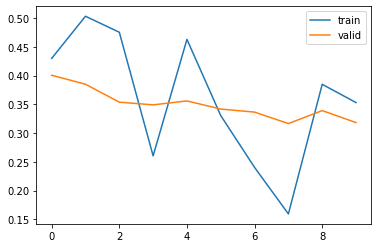

In [35]:
plt.plot(t_loss_his, label="train")
plt.plot(v_loss_his, label="valid")
plt.legend()
plt.show()

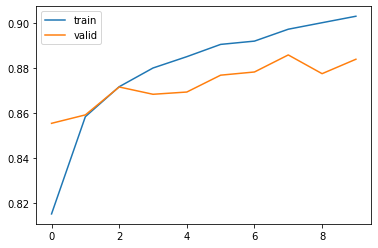

In [36]:
plt.plot(t_acc_his, label="train")
plt.plot(v_acc_his, label="valid")
plt.legend()
plt.show()

In [37]:
v_loss, v_acc = evaluate(model, test_loader)
print("Test Loss : {:.4f}\t accuracy: {:.2f}%\n".format(v_loss, v_acc*100.))

  0%|          | 0/313 [00:00<?, ?it/s]

Test Loss : 0.3200	 accuracy: 88.69%



### CNN

In [50]:
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")

model = CNN().to(DEVICE)
opt = optim.Adam(model.parameters())

print("Model :", model)
print("Device :", DEVICE)
print("model's number of Parameters: ", sum([p.numel() for p in model.parameters()]))

Model : CNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): AdaptiveAvgPool2d(output_size=1)
  (fc1): Linear(in_features=64, out_features=24, bias=True)
  (fc2): Linear(in_features=24, out_features=10, bias=True)
  (act_fn): ReLU()
)
Device : cuda
model's number of Parameters:  26194


In [51]:
# 학습 시작 #
t_loss_his, t_acc_his, v_loss_his, v_acc_his = train(EPOCHS = 10, model = model, train_loader = train_loader, opt = opt)

<<< EPOCH 1 >>>


  0%|          | 0/1500 [00:00<?, ?it/s]

Training : [3200/48000 (7%)]	Loss: 0.924233	 Acc : 0.022
Training : [6400/48000 (13%)]	Loss: 1.126256	 Acc : 0.064
Training : [9600/48000 (20%)]	Loss: 0.929256	 Acc : 0.110
Training : [12800/48000 (27%)]	Loss: 0.737517	 Acc : 0.158
Training : [16000/48000 (33%)]	Loss: 0.811169	 Acc : 0.206
Training : [19200/48000 (40%)]	Loss: 0.447025	 Acc : 0.255
Training : [22400/48000 (47%)]	Loss: 0.779283	 Acc : 0.306
Training : [25600/48000 (53%)]	Loss: 0.512374	 Acc : 0.357
Training : [28800/48000 (60%)]	Loss: 0.446897	 Acc : 0.409
Training : [32000/48000 (67%)]	Loss: 0.489407	 Acc : 0.461
Training : [35200/48000 (73%)]	Loss: 0.556380	 Acc : 0.514
Training : [38400/48000 (80%)]	Loss: 0.504488	 Acc : 0.567
Training : [41600/48000 (87%)]	Loss: 0.692546	 Acc : 0.620
Training : [44800/48000 (93%)]	Loss: 0.338743	 Acc : 0.674


  0%|          | 0/375 [00:00<?, ?it/s]

[1] valid Loss : 0.4866	 accuracy: 82.03%

<<< EPOCH 2 >>>


...

[9] valid Loss : 0.3039	 accuracy: 88.92%

<<< EPOCH 10 >>>


  0%|          | 0/1500 [00:00<?, ?it/s]

Training : [3200/48000 (7%)]	Loss: 0.071689	 Acc : 0.062
Training : [6400/48000 (13%)]	Loss: 0.372380	 Acc : 0.122
Training : [9600/48000 (20%)]	Loss: 0.183866	 Acc : 0.183
Training : [12800/48000 (27%)]	Loss: 0.215200	 Acc : 0.243
Training : [16000/48000 (33%)]	Loss: 0.241592	 Acc : 0.304
Training : [19200/48000 (40%)]	Loss: 0.245558	 Acc : 0.364
Training : [22400/48000 (47%)]	Loss: 0.232143	 Acc : 0.425
Training : [25600/48000 (53%)]	Loss: 0.075748	 Acc : 0.486
Training : [28800/48000 (60%)]	Loss: 0.211350	 Acc : 0.547
Training : [32000/48000 (67%)]	Loss: 0.104605	 Acc : 0.608
Training : [35200/48000 (73%)]	Loss: 0.303439	 Acc : 0.669
Training : [38400/48000 (80%)]	Loss: 0.047444	 Acc : 0.731
Training : [41600/48000 (87%)]	Loss: 0.357652	 Acc : 0.791
Training : [44800/48000 (93%)]	Loss: 0.408557	 Acc : 0.851


  0%|          | 0/375 [00:00<?, ?it/s]

[10] valid Loss : 0.2903	 accuracy: 89.40%



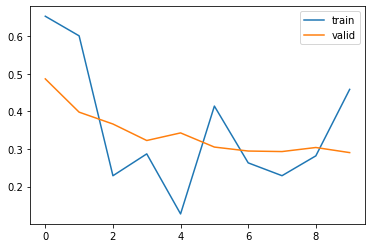

In [52]:
plt.plot(t_loss_his, label="train")
plt.plot(v_loss_his, label="valid")
plt.legend()
plt.show()

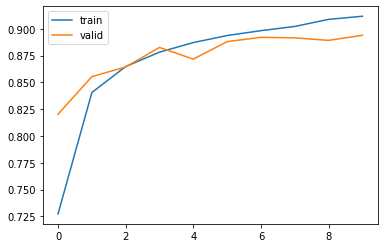

In [53]:
plt.plot(t_acc_his, label="train")
plt.plot(v_acc_his, label="valid")
plt.legend()
plt.show()

In [56]:
v_loss, v_acc = evaluate(model, test_loader)
print("Test Loss : {:.4f}\t accuracy: {:.2f}%\n".format(v_loss, v_acc*100.))

  0%|          | 0/313 [00:00<?, ?it/s]

Test Loss : 0.2823	 accuracy: 90.00%

